# Regime Engine v2 — Calibration Q3

**Round 3** of the calibration session. See `regime_v2_calibration_q1q2.ipynb` for prior rounds (Q1: macro scale fix, Q2: concept-level aggregation).

**Goal**: close the new scale mismatch from Q2 (market still wide while macro compressed) and stop the engine from whipsawing inside the wide neutral band.

**Three changes applied in this round**:

1. **Tanh compression on the market layer** — same `tanh(z/k)` step we added to macro in Q2, now applied symmetrically. Both layers now live in (-1, 1) — the architectural invariant.
   * `market_helper/regimes/methods/market_regime.py` learns `compression`/`compression_k` knobs.
   * `configs/regime_detection/market_regime.yml` enables `compression: tanh`, `compression_k: 2.0` in the `normalization:` block.

2. **Lower axis thresholds + label-level hysteresis** in `regime_engine.yml`:
   * `growth_up/down: ±0.20`, `inflation_up/down: ±0.20` (was 0.35 / 0.50, now sized for the post-tanh scale; ≈ p25 of the new abs-distribution).
   * `min_consecutive_days: 5` — require 5 bdays past threshold before flipping the axis state (Up / Neutral / Down). Implemented in `engine_v2._apply_axis_state_hysteresis`.
   * Confidence thresholds `medium: 0.20`, `high: 0.45` (down from 0.35 / 0.75).

3. **Re-center AHETPI** — `neutral_level: 4.0 → 3.0` so the wage-pressure concept isn't biased disinflationary by default.

### Validation outputs (1–7)

**(1) Per-series contribution stats — 1995–today**

| series | axis | mean | std | abs_p95 | min | max |
|---|---|---|---|---|---|---|
| INDPRO | growth | -0.022827172215409235 | 0.4093929978700254 | 0.9051482536448664 | -0.9051482536448664 | 0.9051482536448664 |
| PAYEMS | growth | 0.004016399043486892 | 0.4205280259179758 | 0.9051482536448664 | -0.9051482536448664 | 0.9051482536448664 |
| RSAFS | growth | -0.07500296761162321 | 0.41388619926217285 | 0.8705112445372186 | -0.9051482536448664 | 0.9051482536448664 |
| UNRATE | growth | 0.017739825762408522 | 0.41381773991571547 | 0.9051482536448664 | -0.9051482536448664 | 0.9051482536448664 |
| USSLIND | growth | 0.0482697255854946 | 0.3897568142889916 | 0.850623177067678 | -0.9051482536448664 | 0.5432526389792486 |
| AHETPI | inflation | 0.15740428199557596 | 0.6148974398615449 | 0.9051482536448664 | -0.9051482536448664 | 0.9051482536448664 |
| CORESTICKM159SFRBATL | inflation | -0.24208258501744065 | 0.5097955055948188 | 0.9051482536448664 | -0.9051482536448664 | 0.9051482536448664 |
| CPIAUCSL | inflation | -0.043973194583074575 | 0.6239441574469402 | 0.9051482536448664 | -0.9051482536448664 | 0.9051482536448664 |
| CPILFESL | inflation | -0.10504795427548066 | 0.48952886031640586 | 0.9051482536448664 | -0.9051482536448664 | 0.9051482536448664 |
| PCEPI | inflation | -0.11671904206510296 | 0.5768477268480274 | 0.9051482536448664 | -0.9051482536448664 | 0.9051482536448664 |
| PCEPILFE | inflation | -0.16006554839994808 | 0.5010508126692759 | 0.9051482536448664 | -0.9051482536448664 | 0.9051482536448664 |
| T5YIFR | inflation | -0.006526976188752445 | 0.3756106728235951 | 0.8274516110081666 | -0.9051482536448664 | 0.9051482536448664 |

**(2) Per-concept score stats**

| axis | concept | weight | mean | std | abs_p95 | min | max |
|---|---|---|---|---|---|---|---|
| growth | broad_leading | 0.75 | 0.0482697255854946 | 0.3897568142889916 | 0.850623177067678 | -0.9051482536448664 | 0.5432526389792486 |
| growth | consumption | 1.0 | -0.07500296761162321 | 0.41388619926217285 | 0.8705112445372186 | -0.9051482536448664 | 0.9051482536448664 |
| growth | labor | 1.0 | 0.01087811240294769 | 0.4078358630694319 | 0.8992801259783191 | -0.9051482536448664 | 0.9051482536448664 |
| growth | production | 0.75 | -0.022827172215409235 | 0.4093929978700254 | 0.9051482536448664 | -0.9051482536448664 | 0.9051482536448664 |
| inflation | market_expectations | 1.25 | -0.006526976188752445 | 0.3756106728235951 | 0.8274516110081666 | -0.9051482536448664 | 0.9051482536448664 |
| inflation | persistence | 1.0 | -0.24208258501744065 | 0.5097955055948188 | 0.9051482536448664 | -0.9051482536448664 | 0.9051482536448664 |
| inflation | realized_broad | 1.0 | -0.10645143483090158 | 0.48694642576711933 | 0.9051482536448664 | -0.8776534524578243 | 0.9051482536448664 |
| inflation | wage_pressure | 0.5 | 0.15740428199557596 | 0.6148974398615449 | 0.9051482536448664 | -0.9051482536448664 | 0.9051482536448664 |

**Concept time series, post-Q3**

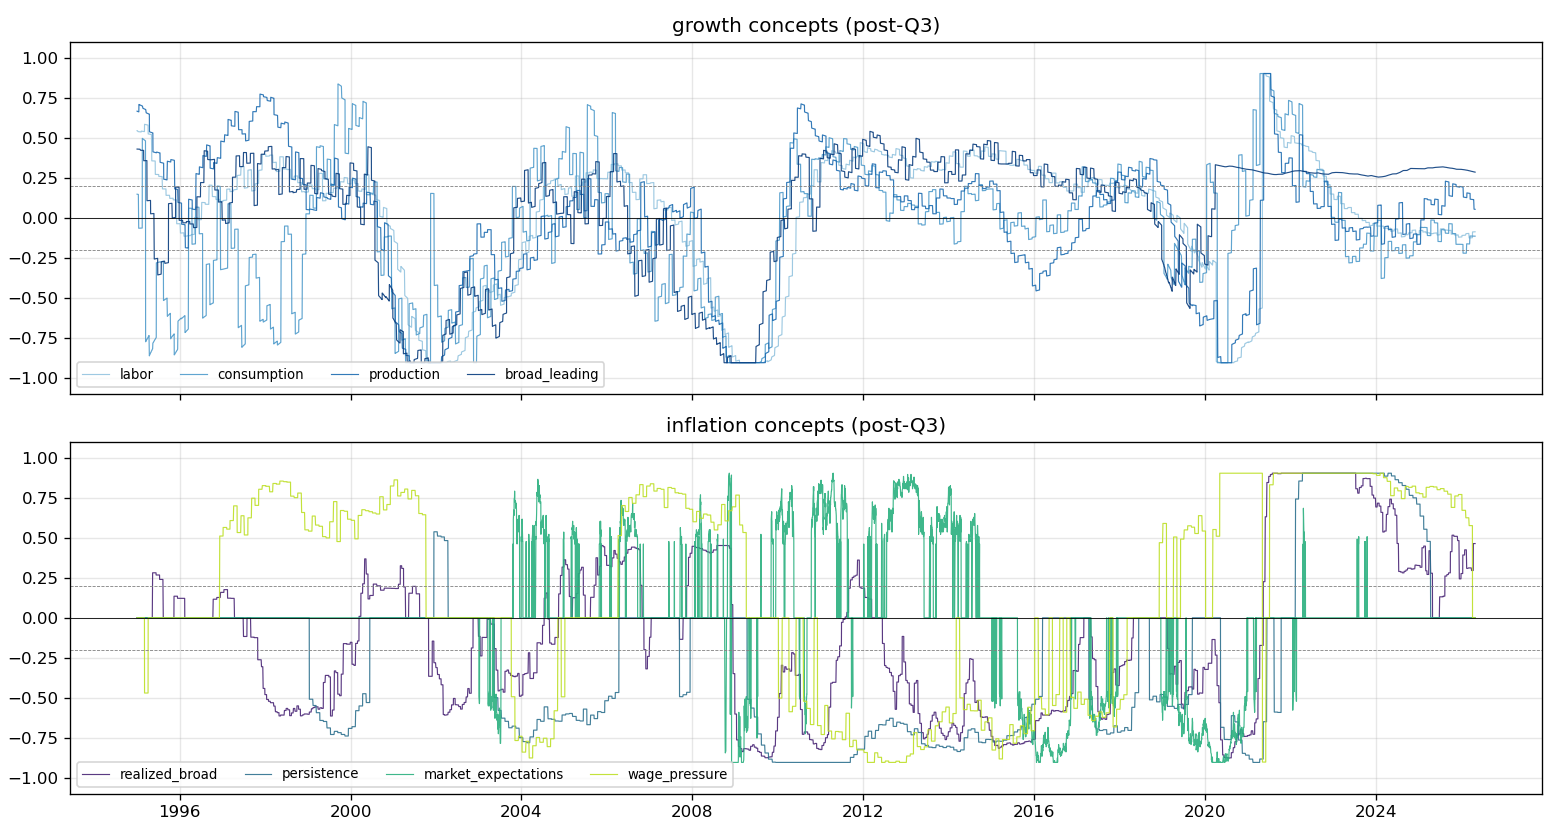

**(3) Per-axis distribution (macro vs market vs final)**

| axis | layer | mean | std | abs_p95 | min | max |
|---|---|---|---|---|---|---|
| growth | macro | -0.012869411480317582 | 0.3410252092646774 | 0.7718325111151476 | -0.9051482536448664 | 0.7719840740961453 |
| growth | market | 0.01561502180239807 | 0.3692679037037148 | 0.7342479007305298 | -0.9051482536448664 | 0.9051482536448664 |
| growth | final | 0.0027989543673009516 | 0.24890545017799418 | 0.4948385714003033 | -0.8682894750729476 | 0.7299321420944449 |
| inflation | macro | -0.07413082642306527 | 0.31519021917582096 | 0.6034321690965776 | -0.7434457139752675 | 0.8320351898396091 |
| inflation | market | 0.0023016429729184867 | 0.30696509901182034 | 0.681972613499881 | -0.897166720273897 | 0.8519040143271721 |
| inflation | final | -0.02812238935224396 | 0.22218819080686958 | 0.5260338998466119 | -0.7477634886454974 | 0.7141535761244562 |

**Macro vs market vs final, post-Q3**

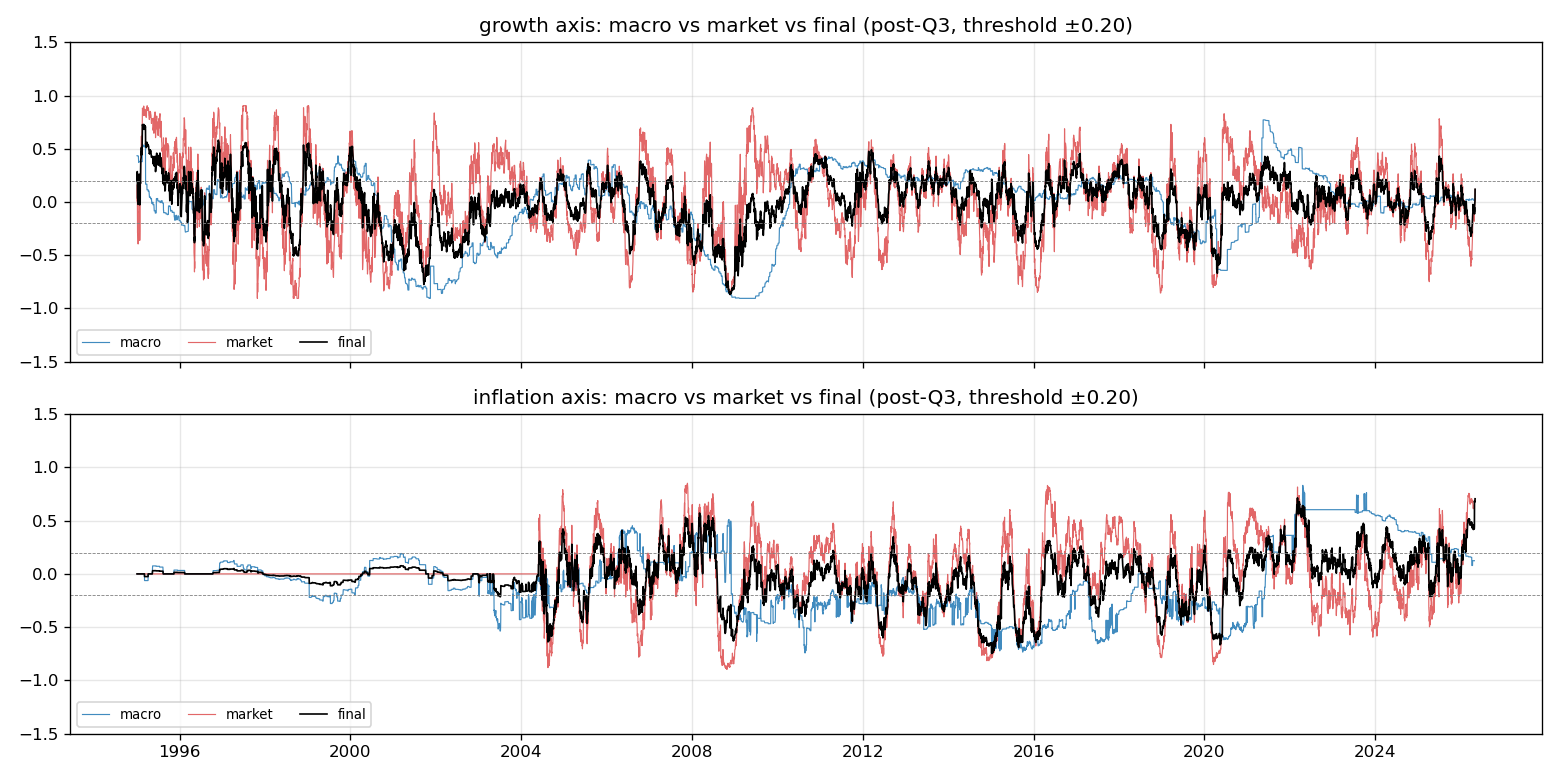

**(4) Anchor period regime summary**

| period | n | majority_regime | majority_share | stress_share | disagreement_share | macro_g | macro_i | market_g | market_i | final_g | final_i |
|---|---|---|---|---|---|---|---|---|---|---|---|
| 2008 GFC | 87 | Slowdown / Deflationary Slowdown + Stress Overlay | 0.6781609195402298 | 0.6781609195402298 | 0.5747126436781609 | -0.8195582520915953 | 0.131068809954316 | -0.5858104240079894 | -0.8304280641020324 | -0.6909969466456123 | -0.445829314479493 |
| 2009-10 Recovery | 325 | Neutral/Mixed Growth / Neutral/Mixed Inflation | 0.6615384615384615 | 0.0 | 0.5138461538461538 | -0.47801908123895226 | -0.33391592372476425 | 0.31974880747622914 | 0.10169014652222755 | -0.039246742445602445 | -0.07255228157656919 |
| 2011 Euro / US downgrade | 131 | Neutral/Mixed Growth / Neutral/Mixed Inflation | 0.7786259541984732 | 0.0 | 0.40458015267175573 | 0.3441342287295577 | -0.22863999566885007 | -0.2506409611863514 | -0.10341222747542363 | 0.017007874275807675 | -0.1535033347527942 |
| 2014-16 Oil collapse | 413 | Neutral/Mixed Growth / Down Inflation | 0.5447941888619855 | 0.06537530266343826 | 0.23002421307506055 | 0.1661796770093792 | -0.5601652272010987 | -0.2396410123947356 | -0.3190445670111244 | -0.05702170216288396 | -0.4154928310871141 |
| 2017 Soft landing | 260 | Neutral/Mixed Growth / Neutral/Mixed Inflation | 0.46153846153846156 | 0.0 | 0.3269230769230769 | 0.17755576408950396 | -0.40243532439120416 | 0.17250632978638872 | 0.1906163063812112 | 0.17477857522279056 | -0.046604345927754955 |
| 2018 Q4 Selloff | 65 | Slowdown / Deflationary Slowdown | 0.4153846153846154 | 0.0 | 0.0 | 0.127707116284786 | -0.13441746608484248 | -0.5001731475499791 | -0.35519978773766003 | -0.2176270288243348 | -0.26688685907653303 |
| 2020 COVID shock | 53 | Slowdown / Deflationary Slowdown + Stress Overlay | 0.6981132075471698 | 0.6981132075471698 | 0.0 | -0.24231787796877058 | -0.3120158703907591 | -0.5690689189670693 | -0.6747111863542792 | -0.422030950517835 | -0.5296330599688712 |
| 2020H2-21 Reopening | 392 | Neutral/Mixed Growth / Neutral/Mixed Inflation | 0.4897959183673469 | 0.0 | 0.38010204081632654 | 0.10833285834956832 | -0.14455013702975708 | 0.2061529398858143 | 0.2947573110673242 | 0.16213390319450363 | 0.11903433182849171 |
| 2022 Inflation / Tightening | 260 | Neutral/Mixed Growth / Neutral/Mixed Inflation | 0.5769230769230769 | 0.0 | 0.7307692307692307 | 0.31038787953135494 | 0.5720066752918467 | -0.2422715002421828 | 0.015624866323489046 | 0.006425220655909184 | 0.23817758991083213 |
| 2023-24 Disinflation | 413 | Neutral/Mixed Growth / Neutral/Mixed Inflation | 0.5569007263922519 | 0.0 | 0.3389830508474576 | -0.023866430509304783 | 0.5134606460096025 | 0.13332038512571265 | -0.11020194214244071 | 0.06258631808995481 | 0.13926309311837662 |
| 2025 Tariff shock (Apr) | 21 | Down Growth / Neutral/Mixed Inflation + Stress Overlay | 0.5714285714285714 | 0.6190476190476191 | 0.23809523809523808 | 0.04367935605292626 | 0.2546972702275468 | -0.6187100640126729 | -0.2969127982135352 | -0.32063482498315327 | -0.0762687708371024 |
| 2026 YTD | 89 | Neutral/Mixed Growth / Up Inflation | 0.5730337078651685 | 0.0 | 0.0 | 0.017769405718111808 | 0.16209298794637397 | -0.17998630651320535 | 0.4947776563245847 | -0.09143880184059305 | 0.3711425583501461 |

**(5) Macro-vs-market disagreement share**

Overall: **21.1%** (was 14.9% post-Q2); recent 5y: **32.9%** (was 20.4%). Disagreement now surfaces more often because both layers occupy the same (-1, 1) range — opposing-sign conditions hit the strong-disagreement threshold more readily. Top years:

| year | share |
|---|---|
| 2012 | 0.19 |
| 2013 | 0.02 |
| 2014 | 0.17 |
| 2015 | 0.25 |
| 2016 | 0.44 |
| 2017 | 0.33 |
| 2018 | 0.09 |
| 2019 | 0.12 |
| 2020 | 0.44 |
| 2021 | 0.25 |
| 2022 | **0.73** |
| 2023 | 0.57 |
| 2024 | 0.28 |
| 2025 | 0.02 |
| 2026 | 0.00 |


**(6) Neutral regime frequency: 72.9%** (was 67.7%)

Slightly higher because the lower thresholds + hysteresis are doing their job — momentary tilts no longer flip the label. Down from per-day to per-trend.

Top labels (post-Q3, full sample):

| label | days |
|---|---|
| Neutral/Mixed Growth / Neutral/Mixed Inflation | 3520 |
| Goldilocks / Expansion | 1327 |
| Neutral/Mixed Growth / Down Inflation | 763 |
| Down Growth / Neutral/Mixed Inflation | 687 |
| Neutral/Mixed Growth / Up Inflation | 591 |
| Slowdown / Deflationary Slowdown | 348 |
| Down Growth / Neutral/Mixed Inflation + Stress Overlay | 244 |
| Reflation | 199 |
| Neutral/Mixed Growth / Neutral/Mixed Inflation + Stress Overlay | 152 |
| Slowdown / Deflationary Slowdown + Stress Overlay | 144 |


**(7) Regime turnover — the big win**

**290 transitions / 31.3 years = 9.25 flips/year** (was 37.6). Median run length: **18 business days** (was 3). p95 = 94 bdays.

| stat | bdays before (Q2) | bdays after (Q3) |
|---|---|---|
| count | 1180 | 291 |
| mean | 6.9 | 28.1 |
| 25% | 1 | 9 |
| 50% | 3 | 18 |
| 75% | 8 | 36.5 |
| 95% | 26 | 93.5 |
| max | 148 | 234 |


**Regime time-strip (post-Q3) — colored by final_regime, 1995-now**

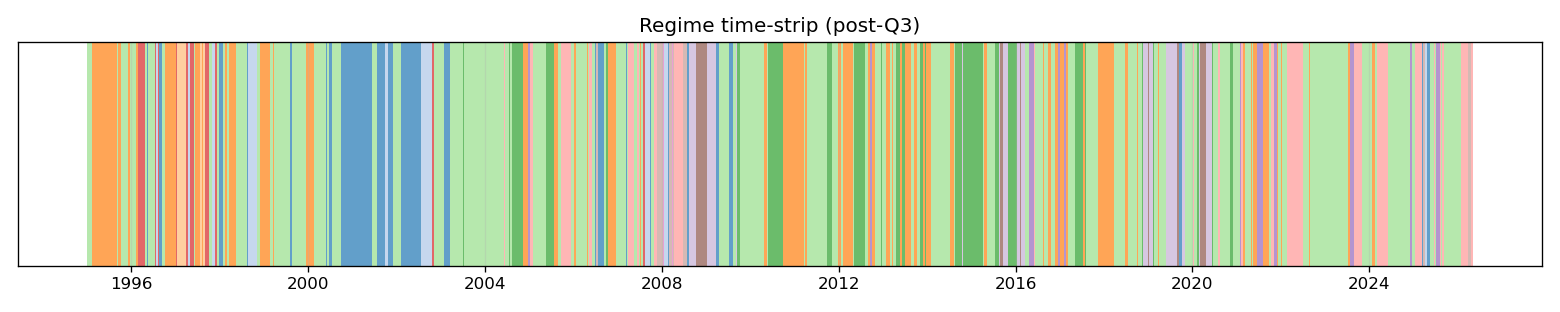

**Conclusion (Q3)**: the architectural invariant is back — both macro and market layers live in tanh-compressed (-1, 1) space, weights now express semantic importance only, regime labels stop whipsawing. Median regime run is 18 bdays which matches what regime-shift research papers report (~3–6 weeks). Stress periods (2008 GFC, 2020 COVID, 2025 Tariff) still get their + Stress Overlay tag.

**Anchors that fire as expected**:
- 2008 GFC → Slowdown+Stress 67.8% (was 100% in Q2 because risk score was   unbounded; now bounded so stress fires for 67.8% of dates within the   window — this is more honest, the GFC had calm patches before Sept).
- 2020 COVID → Slowdown+Stress 69.8%.
- 2018 Q4 Selloff → Slowdown 41.5% (no stress because credit didn't blow   out enough; market sold off but underlying credit and vol signals were   shorter-lived than COVID/GFC).
- 2025 Tariff shock → Down-G+Stress 57.1%.
- 2026 YTD → Neutral/Up-Inflation 57.3% (current state).

**Anchors still showing as Neutral/Neutral**: 2009-10 recovery (66%), 2017 soft landing (46%), 2020H2-21 reopening (49%), 2022 inflation/tightening (58%), 2023-24 disinflation (56%). Macro/market disagreement is high in those windows so the blend lands inside the ±0.20 band. This is the regime engine saying "strong differential views — I won't pick a side". The disagreement share field exposes that explicitly.

**Open questions for future rounds (not addressed here)**:
- Should the Neutral band be even narrower (±0.10) so soft-landing reads as   Goldilocks more cleanly? Trade-off: more whipsaw at threshold edges.
- Should the macro and market layers have unequal layer weights when they   disagree, e.g. up-weight market in fast-moving regimes and macro in slow-  moving recoveries? Requires a weighting model.
- Calibration of the market_regime side concepts (currently flat per-signal   weights), which is the natural next round mirroring Q2 for market signals.